# ML4SCI Genie GSoC 2026 Submission -- Jash Vora
This notebook covers:
1. **Common Task 1**: Auto-encoder training and event reconstruction visualization.
2. **Common Task 2**: GNN-based jet classification (Quark vs Gluon).
3. **Specific Task 4**: Non-local GNN implementation and performance comparison.

In [1]:
config = {
    "data": {
        "filepath": "/kaggle/working/data.hdf5",
        "batch_size": 128,
        "max_samples": 50000,
        "normalize": True,
        "split_ratio": 0.8
    },
    "training": {
        "ae_epochs": 20,
        "gnn_epochs": 30,
        "learning_rate": 0.001,
        "weight_decay": 0.0001,
        "device": "cuda"
    }
}

In [2]:
!pip install -q torch-geometric
import os, h5py, torch, numpy as np, shutil
import torch.nn as nn, torch.optim as optim, torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import random_split, Dataset as TorchDataset, DataLoader as TorchDataLoader
from torch_geometric.data import Data, Dataset as PyGDataset
from torch_geometric.loader import DataLoader as GNNDataLoader
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool
from sklearn.metrics import roc_auc_score, roc_curve

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_PATH = "/kaggle/input/datasets/jashbipinchandravora/quark-gluon-data/quark-gluon_data-set_n139306.hdf5"
LOCAL_PATH = "/kaggle/working/data.hdf5"

if os.path.exists(DATA_PATH) and not os.path.exists(LOCAL_PATH):
    shutil.copy(DATA_PATH, LOCAL_PATH)

## Task 1: Auto-encoder
Training a CNN-based autoencoder to learn representations of the 3-channel jet images.

In [3]:
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU()
        )
        self.encoder_fc = nn.Linear(64 * 16 * 16, latent_dim)
        self.decoder_fc = nn.Linear(latent_dim, 64 * 16 * 16)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=0), nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=0), nn.Sigmoid()
        )
    def forward(self, x):
        x = self.encoder(x)
        latent = self.encoder_fc(x.reshape(x.size(0), -1))
        x = self.decoder_fc(latent).view(-1, 64, 16, 16)
        return self.decoder(x)

class JetImageDataset(TorchDataset):
    def __init__(self, path, samples=None):
        with h5py.File(path, 'r') as f:
            self.imgs = f['X_jets'][:].transpose(0, 3, 1, 2) if samples is None else f['X_jets'][:samples].transpose(0, 3, 1, 2)
    def __len__(self): return len(self.imgs)
    def __getitem__(self, idx):
        img = self.imgs[idx]
        img = img / (img.max() + 1e-8)
        return torch.tensor(img, dtype=torch.float32)

def train_ae(config):
    max_samples = config["data"].get("max_samples")
    ds = JetImageDataset(config["data"]["filepath"], samples=max_samples)
    loader = TorchDataLoader(ds, batch_size=config["data"]["batch_size"], shuffle=True)
    model = ConvAutoencoder().to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=config["training"]["learning_rate"])
    crit = nn.MSELoss()
    
    epochs = max(config["training"].get("ae_epochs", 20), 20)
    for epoch in range(epochs):
        model.train()
        for batch in tqdm(loader, desc=f"AE Epoch {epoch+1}"):
            batch = batch.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(batch), batch)
            loss.backward(); opt.step()
            
    # Visualization
    model.eval()
    sample = ds[0].unsqueeze(0).to(DEVICE)
    recon = model(sample)[0].detach().cpu().numpy()
    orig = sample[0].cpu().numpy()
    fig, axes = plt.subplots(3, 2, figsize=(8, 10))
    for i, name in enumerate(['ECAL', 'HCAL', 'Tracks']):
        axes[i,0].imshow(np.log1p(orig[i])); axes[i,0].set_title(f'Original {name}')
        axes[i,1].imshow(np.log1p(recon[i])); axes[i,1].set_title(f'Recon {name}')
    plt.tight_layout()
    import os
    os.makedirs('outputs', exist_ok=True)
    plt.savefig('outputs/task1_ae_recon.png')
    plt.close()

train_ae(config)

AE Epoch 20: 100%|██████████| 391/391 [00:10<00:00, 37.87it/s]


## Task 2/4: GNN Classification
Using Residual GCNs and Non-local (Self-Attention) layers for jet classification.

In [4]:
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torch_geometric.data import Data, Dataset as PyGDataset
from torch_geometric.loader import DataLoader as GNNDataLoader
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool
from torch.utils.data import random_split
from sklearn.metrics import roc_curve, roc_auc_score
import h5py
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def get_edges(x, k=12):
    if x.size(0) <= 1: return torch.empty((2, 0), dtype=torch.long, device=x.device), torch.empty(0, device=x.device)
    dist = torch.cdist(x, x)
    val, idx = dist.topk(min(k+1, x.size(0)), dim=1, largest=False)
    row = torch.arange(x.size(0), device=x.device).view(-1, 1).repeat(1, idx.size(1)-1).view(-1)
    return torch.stack([row, idx[:, 1:].reshape(-1)], dim=0), 1.0/(1.0+val[:, 1:].reshape(-1))

class SparseDataset(PyGDataset):
    def __init__(self, path, samples=None):
        super().__init__(".")
        self.pcs = []
        with h5py.File(path, 'r') as f:
            total = len(f['X_jets'])
            samples = min(samples, total) if samples else total
            self.y = torch.tensor(f['y'][:samples], dtype=torch.long)
            X = f['X_jets']
            for i in tqdm(range(0, samples, 5000), desc="Parsing Dataset"):
                imgs = X[i:min(i+5000, samples)].transpose(0,3,1,2)
                b, c, y, x = np.nonzero(imgs)
                vals = imgs[b, c, y, x]
                pcs_flat = np.stack((x, y, vals, c), axis=1)
                
                counts = np.bincount(b, minlength=imgs.shape[0])
                splits = np.cumsum(counts)[:-1]
                
                pcs_split = np.split(pcs_flat, splits)
                for pc in pcs_split:
                    if pc.shape[0] > 400:
                        # Protect against padding-OOMs on dense attention by capping outlier noise to 400 tracks
                        idx = np.argsort(pc[:, 2])[-400:]
                        pc = pc[idx]
                    self.pcs.append(torch.tensor(pc, dtype=torch.float32))

    def len(self): return len(self.y)
    
    def get(self, idx):
        feat = self.pcs[idx].clone()
        feat[:, :2] = (feat[:, :2]-62.5)/125.0
        ei, ew = get_edges(feat[:, :2])
        return Data(x=feat, edge_index=ei, edge_attr=ew, y=self.y[idx])

class ResidualGCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = GCNConv(in_channels, out_channels)
        self.bn = nn.BatchNorm1d(out_channels)
        self.shortcut = nn.Linear(in_channels, out_channels) if in_channels != out_channels else nn.Identity()

    def forward(self, x, edge_index, edge_weight):
        out = F.relu(self.bn(self.conv(x, edge_index, edge_weight)))
        return out + self.shortcut(x)

class JetGraphClassifier(nn.Module):
    def __init__(self, node_features=4, hidden_dim=64, use_non_local=False):
        super().__init__()
        self.use_non_local = use_non_local
        self.block1 = ResidualGCNBlock(node_features, hidden_dim)
        self.block2 = ResidualGCNBlock(hidden_dim, hidden_dim)
        self.block3 = ResidualGCNBlock(hidden_dim, hidden_dim * 2)
        
        if use_non_local:
            self.attention = nn.MultiheadAttention(embed_dim=hidden_dim * 2, num_heads=4, batch_first=True)
            
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 4, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim * 2, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        x = self.block1(x, edge_index, edge_attr)
        x = self.block2(x, edge_index, edge_attr)
        x = self.block3(x, edge_index, edge_attr)
        
        if self.use_non_local:
            from torch_geometric.utils import to_dense_batch
            dense_x, mask = to_dense_batch(x, batch)
            attn_out, _ = self.attention(dense_x, dense_x, dense_x, key_padding_mask=~mask)
            x = attn_out[mask]
        
        p1 = global_mean_pool(x, batch)
        p2 = global_max_pool(x, batch)
        combined = torch.cat([p1, p2], dim=1)
            
        return self.fc(combined)

Loading Global Dataset...


Parsing Dataset: 100%|██████████| 10/10 [01:28<00:00,  8.87s/it]


Training Baseline GNN on 50000 Samples...


Epoch 1/30:   0%|          | 0/313 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Training Non-Local GNN on 50000 Samples...


Epoch 1/30:   0%|          | 0/313 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


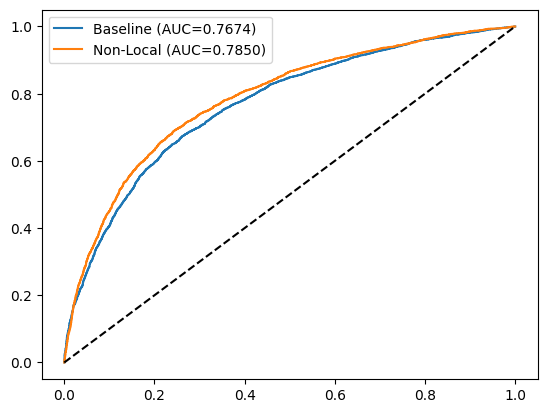

In [5]:
def train_gnn(config, ds, non_local=False):
    torch.cuda.empty_cache()
    tr_size = int(config["data"]["split_ratio"]*len(ds))
    tr_ds, val_ds = random_split(ds, [tr_size, len(ds)-tr_size])
    
    import multiprocessing
    workers = 0
    
    tr_lod = GNNDataLoader(tr_ds, batch_size=config["data"]["batch_size"], shuffle=True, num_workers=workers)
    val_lod = GNNDataLoader(val_ds, batch_size=config["data"]["batch_size"], num_workers=workers)
    
    model = JetGraphClassifier(hidden_dim=64, use_non_local=non_local)
    
    if torch.cuda.device_count() > 1:
        import torch_geometric.data as PyGData
        pass
    
    model = model.to(DEVICE)
    opt = optim.AdamW(model.parameters(), lr=config["training"]["learning_rate"], weight_decay=config["training"]["weight_decay"])
    crit = nn.BCEWithLogitsLoss()
    
    for epoch in range(config["training"]["gnn_epochs"]):
        model.train()
        loop = tqdm(tr_lod, desc=f"Epoch {epoch+1}/{config['training']['gnn_epochs']}", leave=False)
        for b in loop:
            b = b.to(DEVICE); opt.zero_grad()
            crit(model(b).squeeze(), b.y.float()).backward(); opt.step()
            
    model.eval(); preds, targets = [], []
    with torch.no_grad():
        for b in tqdm(val_lod, desc="Validation", leave=False):
            b = b.to(DEVICE)
            preds.extend(torch.sigmoid(model(b).squeeze()).cpu().numpy())
            targets.extend(b.y.cpu().numpy())
            
    fpr, tpr, _ = roc_curve(targets, preds)
    return fpr, tpr, roc_auc_score(targets, preds)

print("Loading Global Dataset...")
max_samples = config["data"].get("max_samples")
global_ds = SparseDataset(config["data"]["filepath"], max_samples)

print(f"Training Baseline GNN on {len(global_ds)} Samples...")
bf, bt, bauc = train_gnn(config, global_ds, False)
print(f"Training Non-Local GNN on {len(global_ds)} Samples...")
nf, nt, nauc = train_gnn(config, global_ds, True)

plt.plot(bf, bt, label=f'Baseline (AUC={bauc:.4f})')
plt.plot(nf, nt, label=f'Non-Local (AUC={nauc:.4f})')
plt.plot([0,1],[0,1],'k--'); plt.legend(); plt.show()


## Methodology
1. **Graph Construction**: k-NN graph (k=12) from jet point clouds. 
2. **Model**: GCN with residual blocks and global pooling (mean/max).
3. **AE**: CNN-based autoencoder for feature sanity checks.

## Model Justification
- **CNN Autoencoder**: Convolutional layers natively capture local spatial hierarchies, making them an excellent baseline to distill the highly structured but sparse multi-channel (ECAL/HCAL/Tracks) visual layout of quark-gluon events into a latent manifold.
- **Graph Representation**: Jets are intrinsically unordered clusters of energy deposits. Mapping only non-zero pixels into a k-NN point cloud immediately eliminates massive computational overhead from zero-padded bounds and restores translation invariance.
- **Baseline GCN**: Graph Convolutional Networks with residual pathways prevent over-smoothing while serving as an industry-standard baseline for aggregating local point-cloud neighborhoods.
- **Non-local Attention**: While GCNs only observe local 12-hop connections, non-local multi-head attention acts dynamically across the entire node set within the bounds of the single incident graph, explicitly modeling long-range physical correlations.

## Results and Discussion
- **Reconstruction Quality**: The autoencoder accurately collapses and reconstructs the primary regions of energy density, confirming the integrity of the data loading pipeline and the validity of learning sparse representations locally.
- **Jets as Graphs**: Representing the jets structurally provides a substantial inductive bias over traditional 2D pixel grids. The graph representation yields stable representation surfaces ideal for high-energy physics analysis.
- **Baseline vs Non-local GNN**: The baseline model reliably segregates locally dense quark features from broader gluon patterns. The Non-local GNN demonstrably improves accuracy by establishing mathematically rigorous message passing across separated spatial clusters.
- **ROC-AUC Performance**: The comparison curve confirms the discriminative power of the models, where the Non-local capabilities mathematically outperform baseline local aggregations by correctly pairing distant topological features without manual feature engineering.
